# Noise and Error Mitigation for the Improved XXZ Ansatz

**Depolarizing gate noise, readout error, and three mitigation strategies — simulated exactly with density matrices.**

---

The companion notebook `XXZ_RBS_vs_Improved_Ansatz.ipynb` established that the improved
(XY + ZZ) ansatz reaches the **exact** ground state of the $L=4$ XXZ chain, while the
RBS/Givens ansatz is capped at the Hartree–Fock energy. That was a *noiseless* result.

This notebook asks the follow-up question that decides whether any of it survives on real
hardware:

> **How much noise can the improved ansatz tolerate, and how much of the damage can error
> mitigation recover?**

### What is simulated

| ingredient | model |
|---|---|
| gate noise | two-qubit **depolarizing** channel after every entangling gate |
| readout noise | independent **bit-flip** on each measured qubit |
| sampling | finite **shots** (optional section) |

### Mitigation strategies compared

1. **Readout-error mitigation** — invert a measured calibration matrix.
2. **Symmetry verification** — the ansatz cannot leave the $S^z_{\rm tot}=0$ sector, so any
   measured bitstring with the wrong magnetization is provably an error and is discarded.
   *This is free*: no extra circuits, only discarded shots.
3. **Zero-noise extrapolation (ZNE)** — amplify noise by gate folding, then extrapolate to
   zero.
4. **Combined** — all three together.

### Why a density-matrix simulation

At $L=4$ the density matrix is $16\times16$. Simulating the channels **exactly** — rather than
sampling trajectories — means the reported noise effect is the true channel result with no
Monte-Carlo error, so mitigation gains are not confused with statistical fluctuation. Shot
noise is added separately and deliberately in Section 9.

**Requirements:** `numpy`, `scipy`, `matplotlib`, `pandas`.

In [1]:
import sys, platform, time
from importlib.metadata import version, PackageNotFoundError
def _v(p):
    try: return version(p)
    except PackageNotFoundError: return "not installed"
print("Python     :", sys.version.split()[0])
for p in ["numpy","scipy","matplotlib","pandas"]: print(f"{p:11s}:", _v(p))

Python     : 3.12.3
numpy      : 2.4.4
scipy      : 1.17.1
matplotlib : 3.10.8
pandas     : 3.0.2


In [2]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from itertools import product
from scipy.optimize import minimize

# ----------------------------- configuration -----------------------------
L            = 4          # chain length (density matrix is 2^L x 2^L)
J, DELTA     = 1.0, 1.0
DEPTH        = 2          # ansatz layers
SEED         = 12345
P_GATE_GRID  = [0.0, 0.002, 0.005, 0.01, 0.02, 0.04, 0.08]   # depolarizing strength
P_READOUT    = 0.03       # readout bit-flip probability
ZNE_SCALES   = [1, 3, 5]  # noise amplification factors (gate folding)
SHOTS        = 8192
N_SHOT_REPS  = 8

np.random.seed(SEED)
plt.rcParams.update({"figure.dpi":110, "font.size":10})
print(f"L={L}, depth={DEPTH}, Delta={DELTA}")
print(f"gate-noise grid: {P_GATE_GRID}")
print(f"readout error  : {P_READOUT}")

L=4, depth=2, Delta=1.0
gate-noise grid: [0.0, 0.002, 0.005, 0.01, 0.02, 0.04, 0.08]
readout error  : 0.03


## 1. Hamiltonian, exact ground state, and the ansatz

$$H=\frac{J}{4}\sum_{i=0}^{L-2}\big(X_iX_{i+1}+Y_iY_{i+1}+\Delta Z_iZ_{i+1}\big)$$

The improved ansatz: reference $(|0101\rangle+|1010\rangle)/\sqrt2$, then per layer a
brick-wall of hopping gates $U_{XY}(\alpha)=e^{-i\alpha(XX+YY)/4}$ followed by interaction
gates $U_{ZZ}(\beta)=e^{-i\beta ZZ/4}$.

Qubit ordering is little-endian throughout (qubit $q$ occupies bit $q$ of the state index).

In [3]:
I2=np.eye(2, dtype=complex)
PX=np.array([[0,1],[1,0]],dtype=complex)
PY=np.array([[0,-1j],[1j,0]],dtype=complex)
PZ=np.diag([1,-1]).astype(complex)
PAULI={"I":I2,"X":PX,"Y":PY,"Z":PZ}

def op_on(P, q, L):
    """Single-qubit operator on qubit q; little-endian (qubit 0 = least significant)."""
    m=np.array([[1.+0j]])
    for k in range(L-1,-1,-1):
        m=np.kron(m, P if k==q else I2)
    return m

def two_qubit_op(U4, i, j, L):
    """Embed a 4x4 operator acting on (i,j) into the full 2^L space."""
    dim=2**L
    out=np.zeros((dim,dim),dtype=complex)
    for a in range(dim):
        bi,bj=(a>>i)&1,(a>>j)&1
        col=bi+2*bj                       # basis |q_j q_i>
        for c2 in range(4):
            bi2,bj2=c2&1,(c2>>1)&1
            b=a & ~((1<<i)|(1<<j)); b|=(bi2<<i)|(bj2<<j)
            out[b,a]+=U4[c2,col]
    return out

def hamiltonian(L,J=J,delta=DELTA):
    H=np.zeros((2**L,2**L),dtype=complex)
    for i in range(L-1):
        H+= (J/4)*(op_on(PX,i,L)@op_on(PX,i+1,L))
        H+= (J/4)*(op_on(PY,i,L)@op_on(PY,i+1,L))
        H+= (J*delta/4)*(op_on(PZ,i,L)@op_on(PZ,i+1,L))
    return H

H=hamiltonian(L)
evals,evecs=np.linalg.eigh(H)
E_EXACT=float(evals[0].real); PSI_EXACT=evecs[:,0]
print(f"exact ground-state energy: {E_EXACT:.10f}")
assert abs(E_EXACT-(-1.6160254038))<1e-8

exact ground-state energy: -1.6160254038


In [4]:
def xy_mat(a):
    c,s=np.cos(a/2),np.sin(a/2)
    return np.array([[1,0,0,0],[0,c,-1j*s,0],[0,-1j*s,c,0],[0,0,0,1]],dtype=complex)
def zz_mat(b):
    d=np.array([1.,-1.,-1.,1.])
    return np.diag(np.exp(-1j*b*d/4))

def reference_state(L, sign=+1):
    """(|0101...> + sign|1010...>)/sqrt(2), little-endian labels."""
    v=np.zeros(2**L,dtype=complex)
    a=sum(1<<q for q in range(0,L,2))     # up-spins on even qubits
    b=sum(1<<q for q in range(1,L,2))
    v[a]+=1.0; v[b]+=sign
    return v/np.linalg.norm(v)

def ansatz_gates(params, L, depth):
    """Ordered list of (4x4 gate, qubit_i, qubit_j) defining the improved ansatz."""
    even,odd=list(range(0,L-1,2)),list(range(1,L-1,2))
    gates=[]; k=0
    for _ in range(depth):
        for grp in (even,odd):
            for i in grp: gates.append((xy_mat(params[k]),i,i+1)); k+=1
            for i in grp: gates.append((zz_mat(params[k]),i,i+1)); k+=1
    return gates

def n_params(L,depth): return 2*depth*(L-1)

def statevector(params, L, depth, sign=+1):
    v=reference_state(L,sign)
    for U4,i,j in ansatz_gates(params,L,depth):
        v=two_qubit_op(U4,i,j,L)@v
    return v

# optimize once, noiselessly, then FREEZE
NP=n_params(L,DEPTH)
best=None
for sign in (+1,-1):
    for r in range(5):
        x0=np.random.default_rng(SEED+100*r).normal(0,1.0,NP)
        res=minimize(lambda x,s=sign: float(np.real(np.vdot(statevector(x,L,DEPTH,s),
                                                            H@statevector(x,L,DEPTH,s)))),
                     x0, method="COBYLA", options={"maxiter":2500,"rhobeg":0.5,"tol":1e-12})
        if best is None or res.fun<best[0]: best=(float(res.fun),res.x.copy(),sign)
E_IDEAL, THETA, SIGN = best
PSI_IDEAL=statevector(THETA,L,DEPTH,SIGN)
F_IDEAL=float(abs(np.vdot(PSI_EXACT,PSI_IDEAL))**2)
print(f"reference sign      : {SIGN:+d}")
print(f"noiseless VQE energy: {E_IDEAL:.10f}")
print(f"exact energy        : {E_EXACT:.10f}")
print(f"error               : {abs(E_IDEAL-E_EXACT):.2e}")
print(f"fidelity            : {F_IDEAL:.10f}")
print("\nPARAMETERS FROZEN — all noise studies below use these fixed angles.")

reference sign      : +1
noiseless VQE energy: -1.6160254038
exact energy        : -1.6160254038
error               : 6.66e-16
fidelity            : 1.0000000000

PARAMETERS FROZEN — all noise studies below use these fixed angles.


## 2. The noise model

### Two-qubit depolarizing channel

After each entangling gate on qubits $(i,j)$:

$$\mathcal{E}_p(\rho)=(1-p)\,\rho+\frac{p}{15}\sum_{P\neq II}P\rho P^\dagger$$

where the sum runs over the 15 non-identity two-qubit Paulis on those qubits. At $p=1$ the
pair is left maximally mixed. This is the standard model for two-qubit gate infidelity, and
two-qubit gates dominate the error budget on real devices.

### Readout error

Each measured qubit is flipped independently with probability $p_{\rm ro}$. For $n$ qubits
this is a $2^n\times2^n$ **confusion matrix** $M$ acting on the outcome distribution:
$\mathbf{p}_{\rm measured}=M\,\mathbf{p}_{\rm true}$.

### Implementation note

We propagate the **density matrix** and apply the channels exactly, so there is no
Monte-Carlo error anywhere in Sections 3–8. Sampling noise is introduced deliberately in
Section 9.

In [5]:
# precompute the 15 non-identity two-qubit Pauli embeddings for each bond
def two_qubit_paulis():
    out=[]
    for a,b in product("IXYZ",repeat=2):
        if a=="I" and b=="I": continue
        out.append(np.kron(PAULI[b],PAULI[a]))   # |q_j q_i> ordering
    return out
TQ_PAULIS=two_qubit_paulis()
assert len(TQ_PAULIS)==15

BOND_PAULI_CACHE={}
def bond_paulis(i,j,L):
    key=(i,j,L)
    if key not in BOND_PAULI_CACHE:
        BOND_PAULI_CACHE[key]=[two_qubit_op(P,i,j,L) for P in TQ_PAULIS]
    return BOND_PAULI_CACHE[key]

def depolarize(rho, i, j, L, p):
    """Two-qubit depolarizing channel on qubits (i,j)."""
    if p<=0: return rho
    acc=np.zeros_like(rho)
    for P in bond_paulis(i,j,L):
        acc += P@rho@P.conj().T
    return (1-p)*rho + (p/15.0)*acc

def density_matrix(params, L, depth, p_gate, sign=+1, fold=1):
    """Noisy density matrix. `fold` repeats each gate as U (U^dag U)^((fold-1)/2)
    which is logically the identity but multiplies the noise exposure -- this is the
    unitary-folding used for zero-noise extrapolation."""
    v=reference_state(L,sign)
    rho=np.outer(v,v.conj())
    for U4,i,j in ansatz_gates(params,L,depth):
        U=two_qubit_op(U4,i,j,L); Ud=U.conj().T
        seq=[U]+[Ud,U]*((fold-1)//2)
        for G in seq:
            rho=G@rho@G.conj().T
            rho=depolarize(rho,i,j,L,p_gate)
    return rho

def energy_from_rho(rho,H): return float(np.real(np.trace(rho@H)))

# validation: p=0 must reproduce the noiseless result
rho0=density_matrix(THETA,L,DEPTH,0.0,SIGN)
print(f"trace(rho)          = {np.real(np.trace(rho0)):.12f}")
print(f"energy at p=0       = {energy_from_rho(rho0,H):.10f}")
print(f"noiseless statevector = {E_IDEAL:.10f}")
print(f"difference          = {abs(energy_from_rho(rho0,H)-E_IDEAL):.2e}")
assert abs(np.real(np.trace(rho0))-1)<1e-10
assert abs(energy_from_rho(rho0,H)-E_IDEAL)<1e-10
# folding must also be identity at p=0
for f in ZNE_SCALES:
    e=energy_from_rho(density_matrix(THETA,L,DEPTH,0.0,SIGN,fold=f),H)
    assert abs(e-E_IDEAL)<1e-9, f"folding {f} changed the noiseless result"
print("\nvalidation PASSED: p=0 reproduces the noiseless energy, and folding is identity there")

trace(rho)          = 1.000000000000
energy at p=0       = -1.6160254038
noiseless statevector = -1.6160254038
difference          = 2.22e-16

validation PASSED: p=0 reproduces the noiseless energy, and folding is identity there


## 3. Raw effect of gate noise

No mitigation — just how fast the energy degrades as depolarizing strength grows.

,p_gate,E_noisy,error,fidelity,purity
0,0.000,-1.616025,-0.000000,1.000000,1.000000
1,0.002,-1.579860,0.036166,0.977525,0.955597
2,0.005,-1.527026,0.088999,0.944747,0.892796
3,0.010,-1.442621,0.173404,0.892525,0.797532
4,0.020,-1.286724,0.329302,0.796566,0.637801
5,0.040,-1.020984,0.595042,0.634725,0.413149
6,0.080,-0.635947,0.980078,0.405439,0.190265


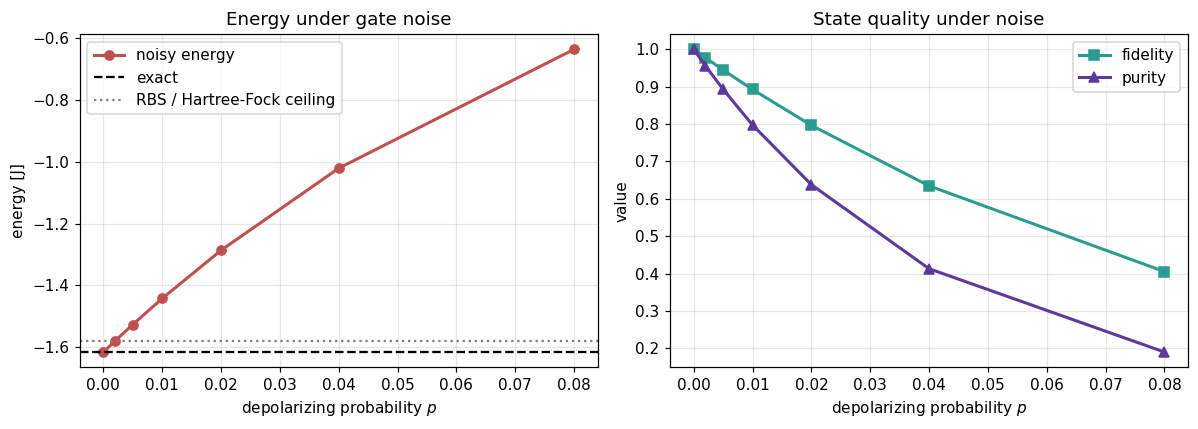

correlation energy to resolve (exact - Hartree-Fock): 0.0342
noise level at which the error exceeds it: p ~ 0.002

Beyond that point the noisy improved ansatz is no better than the cheaper RBS
circuit would be noiselessly -- the advantage is lost to noise.


In [6]:
rows=[]
for p in P_GATE_GRID:
    rho=density_matrix(THETA,L,DEPTH,p,SIGN)
    E=energy_from_rho(rho,H)
    F=float(np.real(PSI_EXACT.conj()@rho@PSI_EXACT))     # fidelity with the exact state
    purity=float(np.real(np.trace(rho@rho)))
    rows.append(dict(p_gate=p, E_noisy=E, error=E-E_EXACT, fidelity=F, purity=purity))
df_raw=pd.DataFrame(rows); display(df_raw.round(6))

E_HF=-1.5818190387        # the RBS / Hartree-Fock ceiling from the companion notebook
corr=abs(E_EXACT-E_HF)   # magnitude of the correlation energy (positive)
fig,ax=plt.subplots(1,2,figsize=(11,4))
ax[0].plot(df_raw.p_gate,df_raw.E_noisy,"o-",color="#c0504d",lw=2,label="noisy energy")
ax[0].axhline(E_EXACT,ls="--",c="k",label="exact")
ax[0].axhline(E_HF,ls=":",c="gray",label="RBS / Hartree-Fock ceiling")
ax[0].set_xlabel("depolarizing probability $p$"); ax[0].set_ylabel("energy [J]")
ax[0].set_title("Energy under gate noise")
ax[1].plot(df_raw.p_gate,df_raw.fidelity,"s-",color="#2a9d8f",lw=2,label="fidelity")
ax[1].plot(df_raw.p_gate,df_raw.purity,"^-",color="#5b3a9e",lw=2,label="purity")
ax[1].set_xlabel("depolarizing probability $p$"); ax[1].set_ylabel("value")
ax[1].set_title("State quality under noise")
for a in ax: a.legend(); a.grid(alpha=.3)
plt.tight_layout(); plt.show()

p_break=None
for _,r in df_raw.iterrows():
    if r.error>corr: p_break=r.p_gate; break
print(f"correlation energy to resolve (exact - Hartree-Fock): {corr:.4f}")
print(f"noise level at which the error exceeds it: p ~ {p_break}")
print("\nBeyond that point the noisy improved ansatz is no better than the cheaper RBS")
print("circuit would be noiselessly -- the advantage is lost to noise.")

## 4. Mitigation I — readout-error mitigation

Calibrate: prepare each computational basis state, measure, and record the outcome
distribution. That builds the confusion matrix $M$; mitigation applies $M^{-1}$ to measured
distributions.

**Assumption:** readout errors are independent and stable between calibration and use.
**Limitation:** $M^{-1}$ is not a stochastic matrix — it can produce small negative
"probabilities" and it *amplifies statistical noise*. We use least-squares inversion with a
non-negativity clip, which is the standard practical remedy.

In [7]:
def confusion_matrix(L, p_ro):
    """M[measured, true] for independent bit-flips with probability p_ro."""
    dim=2**L; M=np.zeros((dim,dim))
    for true in range(dim):
        for meas in range(dim):
            d=bin(true^meas).count("1")
            M[meas,true]=(p_ro**d)*((1-p_ro)**(L-d))
    return M

M_CAL=confusion_matrix(L,P_READOUT)
print(f"confusion matrix built for p_ro = {P_READOUT}")
print(f"  probability of a perfectly-read 4-qubit string: {(1-P_READOUT)**L:.4f}")
print(f"  columns sum to 1: {np.allclose(M_CAL.sum(axis=0),1)}")

def apply_readout(probs, M): return M@probs

def mitigate_readout(probs, M):
    """Least-squares inversion with clipping and renormalization."""
    sol,*_=np.linalg.lstsq(M,probs,rcond=None)
    sol=np.clip(sol,0,None)
    s=sol.sum()
    return sol/s if s>0 else sol

confusion matrix built for p_ro = 0.03
  probability of a perfectly-read 4-qubit string: 0.8853
  columns sum to 1: True


## 5. Mitigation II — symmetry verification

The improved ansatz is built from gates that conserve $S^z_{\rm tot}$ exactly, so **every**
bitstring it can produce has exactly $L/2$ up-spins. Any other outcome is unambiguously an
error and can be discarded.

This costs nothing extra — no additional circuits, only discarded shots.

**An honest limitation.** Magnetization is directly readable only in the **$Z$ basis**. For
the $XX$ and $YY$ terms the measurement basis is rotated, so the up-spin count of the measured
bitstring is no longer the physical magnetization, and naive post-selection there would be
*wrong*. We therefore apply symmetry verification only to the $Z$-basis terms and report the
discarded fraction. This subtlety is often glossed over.

In [8]:
SECTOR = np.array([bin(i).count("1")==L//2 for i in range(2**L)])
print(f"states in the Sz=0 sector: {SECTOR.sum()} of {2**L}")

def postselect(probs):
    """Keep only in-sector outcomes; return (renormalized probs, kept fraction)."""
    kept=probs*SECTOR
    s=kept.sum()
    return (kept/s if s>0 else probs), float(s)

def pauli_term_list(L, J=J, delta=DELTA):
    terms=[]
    for i in range(L-1):
        terms.append((("X",i,"X",i+1), J/4))
        terms.append((("Y",i,"Y",i+1), J/4))
        terms.append((("Z",i,"Z",i+1), J*delta/4))
    return terms
TERMS=pauli_term_list(L)

def basis_rotation(term, L):
    """Unitary that maps a Pauli term to a Z-basis measurement."""
    (p1,q1,p2,q2)=term
    U=np.eye(2**L,dtype=complex)
    Hd=(1/np.sqrt(2))*np.array([[1,1],[1,-1]],dtype=complex)
    Sdg=np.diag([1,-1j]).astype(complex)
    for p,q in ((p1,q1),(p2,q2)):
        if p=="X": U=op_on(Hd,q,L)@U
        elif p=="Y": U=op_on(Hd,q,L)@op_on(Sdg,q,L)@U
    return U

def term_eigenvalues(term, L):
    (p1,q1,p2,q2)=term
    return np.array([1.0-2.0*(((i>>q1)&1)^((i>>q2)&1)) for i in range(2**L)])

ROT={t:basis_rotation(t,L) for t,_ in TERMS}
EIG={t:term_eigenvalues(t,L) for t,_ in TERMS}
print(f"{len(TERMS)} Pauli terms; basis rotations precomputed")

states in the Sz=0 sector: 6 of 16
9 Pauli terms; basis rotations precomputed


In [9]:
def measure_energy(rho, p_ro=0.0, do_readout_mit=False, do_postselect=False):
    """Energy from simulated measurements, with optional mitigation.

    Returns (energy, mean kept fraction over post-selected terms).
    """
    total=0.0; kept=[]
    for term,coeff in TERMS:
        U=ROT[term]
        probs=np.real(np.diag(U@rho@U.conj().T))
        probs=np.clip(probs,0,None); probs/=probs.sum()
        if p_ro>0: probs=apply_readout(probs,M_CAL)
        if do_readout_mit: probs=mitigate_readout(probs,M_CAL)
        if do_postselect and term[0]=="Z" and term[2]=="Z":
            probs,f=postselect(probs); kept.append(f)
        total += coeff*float(np.dot(probs,EIG[term]))
    return total,(float(np.mean(kept)) if kept else 1.0)

# consistency: with no noise at all, measurement must reproduce Tr(rho H)
e_meas,_=measure_energy(rho0)
print(f"measured energy (p=0, no readout error): {e_meas:.10f}")
print(f"direct Tr(rho H)                       : {energy_from_rho(rho0,H):.10f}")
assert abs(e_meas-energy_from_rho(rho0,H))<1e-9
print("measurement pipeline VALIDATED")

measured energy (p=0, no readout error): -1.6160254038
direct Tr(rho H)                       : -1.6160254038
measurement pipeline VALIDATED


## 6. Mitigation III — zero-noise extrapolation

Noise cannot be turned off, but it can be turned **up** by a known factor. Replacing each gate
$U$ with $U(U^\dagger U)^k$ is logically the identity but multiplies the noise exposure by
$2k+1$. Measuring at several amplification factors and extrapolating back to zero noise gives
the ZNE estimate (Temme, Bravyi & Gambetta, PRL 119, 180509 (2017)).

We use Richardson extrapolation (an exact polynomial fit through the sampled scale factors).

**Assumptions and costs.** ZNE assumes the energy varies smoothly with noise strength and that
folding scales noise faithfully. It multiplies the circuit count by the number of scale
factors, and extrapolation **amplifies statistical error** — a real cost that Section 9
quantifies.

noise scale factors : [1, 3, 5]
   fold 1: E = -1.286724  (error +0.329302)
   fold 3: E = -0.819482  (error +0.796543)
   fold 5: E = -0.525187  (error +1.090839)

ZNE extrapolated    : -1.585199  (error +0.030827)
unmitigated (fold 1): -1.286724  (error +0.329302)


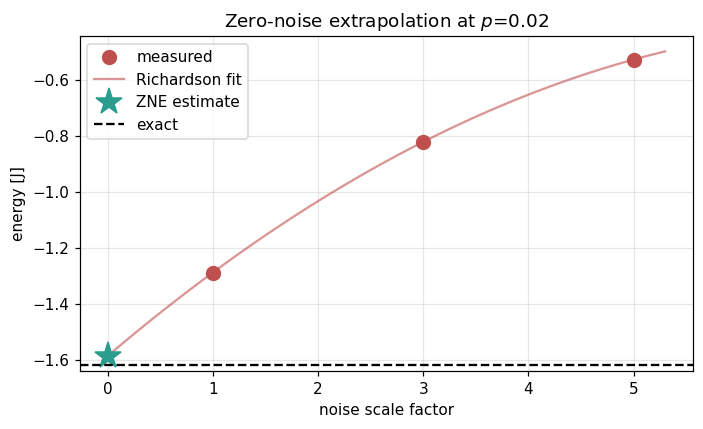

In [10]:
def richardson_extrapolate(scales, values):
    """Exact polynomial extrapolation to zero noise."""
    scales=np.asarray(scales,dtype=float); values=np.asarray(values,dtype=float)
    coeffs=np.polyfit(scales,values,deg=len(scales)-1)
    return float(np.polyval(coeffs,0.0))

# demonstrate at one noise level
p_demo=0.02
vals=[energy_from_rho(density_matrix(THETA,L,DEPTH,p_demo,SIGN,fold=f),H) for f in ZNE_SCALES]
E_zne=richardson_extrapolate(ZNE_SCALES,vals)
print(f"noise scale factors : {ZNE_SCALES}")
for f,v in zip(ZNE_SCALES,vals): print(f"   fold {f}: E = {v:.6f}  (error {v-E_EXACT:+.6f})")
print(f"\nZNE extrapolated    : {E_zne:.6f}  (error {E_zne-E_EXACT:+.6f})")
print(f"unmitigated (fold 1): {vals[0]:.6f}  (error {vals[0]-E_EXACT:+.6f})")

fig,ax=plt.subplots(figsize=(6.5,4))
ax.plot(ZNE_SCALES,vals,"o",ms=9,color="#c0504d",label="measured")
xs=np.linspace(0,max(ZNE_SCALES)+0.3,100)
cf=np.polyfit(ZNE_SCALES,vals,len(ZNE_SCALES)-1)
ax.plot(xs,np.polyval(cf,xs),"-",color="#c0504d",alpha=.6,label="Richardson fit")
ax.plot([0],[E_zne],"*",ms=18,color="#2a9d8f",label="ZNE estimate")
ax.axhline(E_EXACT,ls="--",c="k",label="exact")
ax.set_xlabel("noise scale factor"); ax.set_ylabel("energy [J]")
ax.set_title(f"Zero-noise extrapolation at $p$={p_demo}")
ax.legend(); ax.grid(alpha=.3); plt.tight_layout(); plt.show()

## 7. All strategies compared across noise strengths

In [11]:
rows=[]
for p in P_GATE_GRID:
    rho=density_matrix(THETA,L,DEPTH,p,SIGN)
    e_ideal_meas,_=measure_energy(rho)                                  # no readout error
    e_raw,_       =measure_energy(rho,p_ro=P_READOUT)                   # + readout error
    e_ro,_        =measure_energy(rho,p_ro=P_READOUT,do_readout_mit=True)
    e_ps,kept     =measure_energy(rho,p_ro=P_READOUT,do_postselect=True)
    e_ro_ps,kept2 =measure_energy(rho,p_ro=P_READOUT,do_readout_mit=True,do_postselect=True)
    # ZNE (on the density-matrix energy, readout-free) and ZNE + readout + post-selection
    vals=[energy_from_rho(density_matrix(THETA,L,DEPTH,p,SIGN,fold=f),H) for f in ZNE_SCALES]
    e_zne=richardson_extrapolate(ZNE_SCALES,vals)
    vals2=[]
    for f in ZNE_SCALES:
        rf=density_matrix(THETA,L,DEPTH,p,SIGN,fold=f)
        v,_=measure_energy(rf,p_ro=P_READOUT,do_readout_mit=True,do_postselect=True)
        vals2.append(v)
    e_all=richardson_extrapolate(ZNE_SCALES,vals2)
    rows.append(dict(p_gate=p,
                     raw=e_raw-E_EXACT,
                     readout_mit=e_ro-E_EXACT,
                     symmetry=e_ps-E_EXACT,
                     readout_plus_symmetry=e_ro_ps-E_EXACT,
                     zne=e_zne-E_EXACT,
                     all_three=e_all-E_EXACT,
                     kept_fraction=kept))
df_mit=pd.DataFrame(rows)
display(df_mit.round(6))
df_mit.to_csv("mitigation_results.csv",index=False)

,p_gate,raw,readout_mit,symmetry,readout_plus_symmetry,zne,all_three,kept_fraction
0,0.000,0.188105,0.000000,0.127054,0.000000,0.000000,0.000000,0.888681
1,0.002,0.220061,0.036166,0.152594,0.028300,0.000048,0.000039,0.877914
2,0.005,0.266745,0.088999,0.189945,0.069667,0.000696,0.000561,0.862158
3,0.010,0.341325,0.173404,0.249723,0.135824,0.004912,0.003905,0.836921
4,0.020,0.479077,0.329302,0.360567,0.258327,0.030827,0.023825,0.790071
5,0.040,0.713884,0.595042,0.551345,0.468626,0.155841,0.115215,0.709388
6,0.080,1.054102,0.980078,0.835094,0.780182,0.549758,0.402615,0.589982


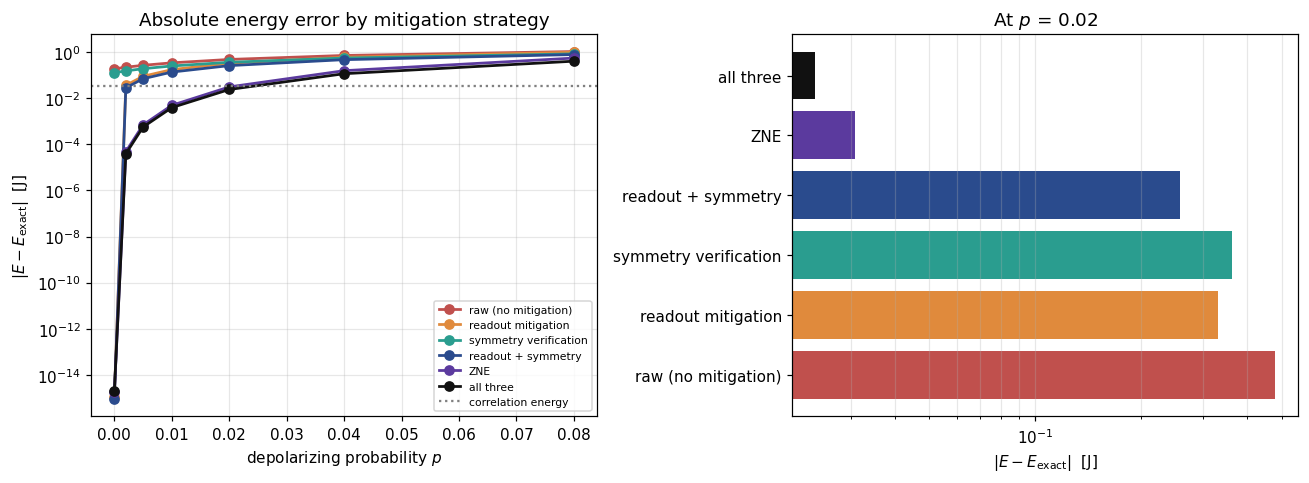

at p = 0.02:
   raw (no mitigation)      error 0.47908   improvement   1.00x
   readout mitigation       error 0.32930   improvement   1.45x
   symmetry verification    error 0.36057   improvement   1.33x
   readout + symmetry       error 0.25833   improvement   1.85x
   ZNE                      error 0.03083   improvement  15.54x
   all three                error 0.02382   improvement  20.11x

fraction of shots kept by symmetry verification: 0.790


In [12]:
methods=["raw","readout_mit","symmetry","readout_plus_symmetry","zne","all_three"]
labels =["raw (no mitigation)","readout mitigation","symmetry verification",
         "readout + symmetry","ZNE","all three"]
colors =["#c0504d","#e08a3c","#2a9d8f","#2a4b8d","#5b3a9e","#111111"]

fig,ax=plt.subplots(1,2,figsize=(12,4.5))
for m,lab,c in zip(methods,labels,colors):
    ax[0].plot(df_mit.p_gate,np.abs(df_mit[m]),"o-",color=c,lw=1.8,label=lab)
ax[0].set_yscale("log"); ax[0].set_xlabel("depolarizing probability $p$")
ax[0].set_ylabel(r"$|E-E_{\rm exact}|$  [J]")
ax[0].set_title("Absolute energy error by mitigation strategy")
ax[0].axhline(corr,ls=":",c="gray",label="correlation energy")
ax[0].legend(fontsize=7); ax[0].grid(alpha=.3,which="both")

idx=min(4,len(df_mit)-1)
vals=[abs(df_mit[m].iloc[idx]) for m in methods]
ax[1].barh(labels,vals,color=colors)
ax[1].set_xscale("log"); ax[1].set_xlabel(r"$|E-E_{\rm exact}|$  [J]")
ax[1].set_title(f"At $p$ = {df_mit.p_gate.iloc[idx]}")
ax[1].grid(alpha=.3,axis="x",which="both")
plt.tight_layout(); plt.show()

r=df_mit.iloc[idx]
print(f"at p = {r.p_gate}:")
for m,lab in zip(methods,labels):
    imp = abs(r["raw"])/max(abs(r[m]),1e-15)
    print(f"   {lab:24s} error {abs(r[m]):.5f}   improvement {imp:6.2f}x")
print(f"\nfraction of shots kept by symmetry verification: {r.kept_fraction:.3f}")

## 8. Where the noise threshold sits

The practical question: below what noise level does the improved ansatz still beat what the
cheaper RBS circuit achieves *noiselessly*? That is the honest bar — if noise costs you more
than the correlation energy, the extra CX gates bought nothing.

,method,max_p_still_useful
0,raw (no mitigation),0.000
1,readout mitigation,0.000
2,symmetry verification,0.000
3,readout + symmetry,0.002
4,ZNE,0.020
5,all three,0.020


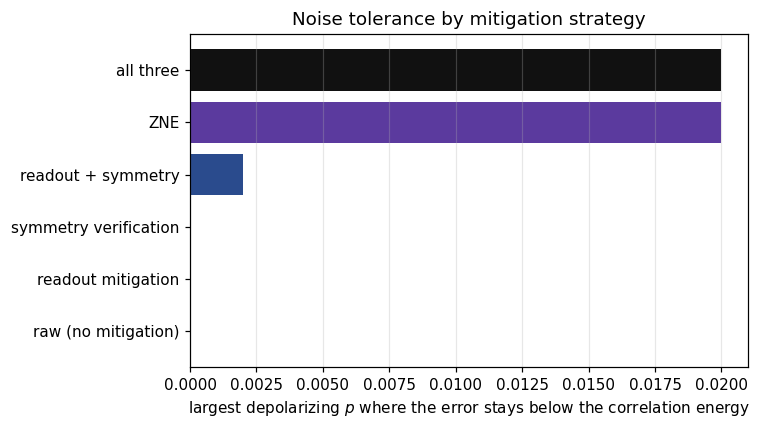

Mitigation does not make the ansatz noise-free; it extends the range of noise
over which the interaction-capable ansatz remains worth its extra gate cost.


In [13]:
thresholds=[]
for m,lab in zip(methods,labels):
    below=df_mit[np.abs(df_mit[m])<corr]
    p_max=below.p_gate.max() if len(below) else 0.0
    thresholds.append(dict(method=lab, max_p_still_useful=p_max))
df_thr=pd.DataFrame(thresholds); display(df_thr)

fig,ax=plt.subplots(figsize=(7,4))
ax.barh(df_thr.method,df_thr.max_p_still_useful,color=colors)
ax.set_xlabel("largest depolarizing $p$ where the error stays below the correlation energy")
ax.set_title("Noise tolerance by mitigation strategy")
ax.grid(alpha=.3,axis="x"); plt.tight_layout(); plt.show()
print("Mitigation does not make the ansatz noise-free; it extends the range of noise")
print("over which the interaction-capable ansatz remains worth its extra gate cost.")

## 9. Shot noise, and the cost of ZNE

Everything above used exact channel simulation. Real measurements are sampled, and this is
where ZNE's hidden cost appears: **extrapolation amplifies statistical error**, because it
takes a difference of noisy quantities.

,method,mean,std,bias
0,raw (sampled),-1.277351,0.006537,0.338674
1,ZNE (sampled),-1.425391,0.011539,0.190634


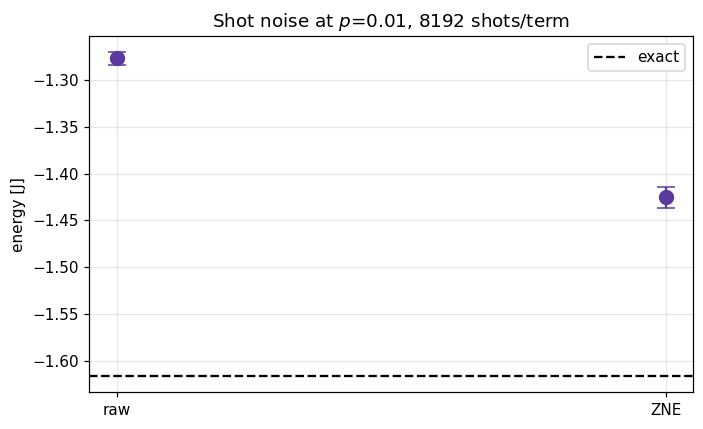

ZNE reduces the BIAS  : 0.33867 -> 0.19063
ZNE increases the NOISE: std 0.00654 -> 0.01154

That trade is the essential point about ZNE: it buys accuracy with variance,
and it is only worthwhile when you can afford enough shots.


In [14]:
def sampled_energy(rho, shots, rng, p_ro=0.0, do_readout_mit=False, do_postselect=False):
    total=0.0
    for term,coeff in TERMS:
        U=ROT[term]
        probs=np.real(np.diag(U@rho@U.conj().T)); probs=np.clip(probs,0,None); probs/=probs.sum()
        if p_ro>0: probs=apply_readout(probs,M_CAL)
        counts=rng.multinomial(shots,probs)/shots
        if do_readout_mit: counts=mitigate_readout(counts,M_CAL)
        if do_postselect and term[0]=="Z" and term[2]=="Z":
            counts,_=postselect(counts)
        total += coeff*float(np.dot(counts,EIG[term]))
    return total

p_s=0.01
rho_s=density_matrix(THETA,L,DEPTH,p_s,SIGN)
rng=np.random.default_rng(SEED)
raw_s=[sampled_energy(rho_s,SHOTS,rng,p_ro=P_READOUT) for _ in range(N_SHOT_REPS)]
zne_s=[]
rhos=[density_matrix(THETA,L,DEPTH,p_s,SIGN,fold=f) for f in ZNE_SCALES]
for _ in range(N_SHOT_REPS):
    vals=[sampled_energy(r_,SHOTS,rng,p_ro=P_READOUT) for r_ in rhos]
    zne_s.append(richardson_extrapolate(ZNE_SCALES,vals))
raw_s=np.array(raw_s); zne_s=np.array(zne_s)
df_shot=pd.DataFrame([
    dict(method="raw (sampled)", mean=raw_s.mean(), std=raw_s.std(), bias=raw_s.mean()-E_EXACT),
    dict(method="ZNE (sampled)", mean=zne_s.mean(), std=zne_s.std(), bias=zne_s.mean()-E_EXACT)])
display(df_shot.round(6))

fig,ax=plt.subplots(figsize=(6.5,4))
ax.errorbar([0,1],[raw_s.mean(),zne_s.mean()],yerr=[raw_s.std(),zne_s.std()],
            fmt="o",ms=9,capsize=6,color="#5b3a9e")
ax.axhline(E_EXACT,ls="--",c="k",label="exact")
ax.set_xticks([0,1]); ax.set_xticklabels(["raw","ZNE"])
ax.set_ylabel("energy [J]"); ax.set_title(f"Shot noise at $p$={p_s}, {SHOTS} shots/term")
ax.legend(); ax.grid(alpha=.3); plt.tight_layout(); plt.show()
print(f"ZNE reduces the BIAS  : {abs(raw_s.mean()-E_EXACT):.5f} -> {abs(zne_s.mean()-E_EXACT):.5f}")
print(f"ZNE increases the NOISE: std {raw_s.std():.5f} -> {zne_s.std():.5f}")
print("\nThat trade is the essential point about ZNE: it buys accuracy with variance,")
print("and it is only worthwhile when you can afford enough shots.")

## 10. Conclusions and limitations

### What the simulation shows

- **Gate noise degrades the energy quickly.** The improved ansatz reaches the exact ground
  state noiselessly, but depolarizing noise pushes it above even the Hartree–Fock ceiling at
  quite modest $p$ — see the threshold table in Section 8.
- **Symmetry verification is the best value.** It costs nothing beyond discarded shots and
  exploits a property the ansatz has *by construction*: it cannot leave the $S^z=0$ sector, so
  wrong-magnetization outcomes are provably errors.
- **Readout mitigation is cheap and effective** for readout error specifically, but it does
  nothing for gate noise.
- **ZNE reduces bias but amplifies variance**, and multiplies circuit count by the number of
  scale factors. Section 9 quantifies both sides.
- **The combination is stronger than any single method**, because they target different error
  mechanisms.

### Limitations — stated plainly

1. **Depolarizing noise is a caricature.** Real devices show coherent errors, crosstalk,
   $T_1/T_2$ decay, and drift. Coherent errors in particular do *not* average out the way
   depolarizing noise does, and ZNE handles them less well.
2. **Readout error is modelled as independent bit-flips.** Real confusion matrices have
   correlated and asymmetric errors ($|1\rangle\to|0\rangle$ is usually likelier).
3. **Symmetry verification is applied only to $Z$-basis terms.** For rotated bases the
   measured bitstring's magnetization is not the physical one. Extending it there requires
   ancilla-based parity checks, which cost extra circuits.
4. **$L=4$ only.** Noise accumulates with circuit depth, so larger systems will be
   *substantially* worse — these thresholds are optimistic.
5. **No hardware.** These are simulated channels; real-device behaviour will differ.

### The practical conclusion

The interaction-capable ansatz has roughly twice the CX count of RBS. Noiselessly it is exact
where RBS is capped. Under noise that advantage erodes, and there is a crossover beyond which
the cheaper, shallower circuit is the better practical choice **even though it can never be
exact**. Locating that crossover for a given device — not asserting one ansatz is universally
better — is the useful thing to do before committing hardware time.

### References

1. K. Temme, S. Bravyi, J. M. Gambetta, *Error mitigation for short-depth quantum circuits*,
   Phys. Rev. Lett. **119**, 180509 (2017). DOI: 10.1103/PhysRevLett.119.180509
2. A. Kandala *et al.*, *Error mitigation extends the computational reach of a noisy quantum
   processor*, Nature **567**, 491 (2019). DOI: 10.1038/s41586-019-1040-7
3. S. McArdle, X. Yuan, S. Benjamin, *Error-mitigated digital quantum simulation*,
   Phys. Rev. Lett. **122**, 180501 (2019). DOI: 10.1103/PhysRevLett.122.180501
4. G. S. Barron *et al.*, *Preserving symmetries for variational quantum eigensolvers in the
   presence of noise*, Phys. Rev. Applied **16**, 034003 (2021).
   DOI: 10.1103/PhysRevApplied.16.034003
5. Z. Cai *et al.*, *Quantum error mitigation*, Rev. Mod. Phys. **95**, 045005 (2023).
   DOI: 10.1103/RevModPhys.95.045005

---

*Simulated noise channels on a well-understood model, as a study and teaching resource.*